In [11]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Annotated # Annotated for reducer
import operator # for reducer
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from pydantic import BaseModel,Field #library to create structuredschema


In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(
    model="llama-3.1-8b-instant",
    
)

In [4]:
# Evaluation Schema
class Evaluationchema(BaseModel):
    feedback :str = Field(description = 'Detailed feedback for the essay')
    score: int = Field(description = 'Score out of 10',ge = 0,le=10)

In [6]:
structured_model = model.with_structured_output(Evaluationchema)

In [7]:
# Testing the model 
essay = """
Education insaan ki zindagi ka bunyadi aur sab se aham pehlu hai. Yeh sirf kitaabi ilm hasil karne ka zariya nahi balkay sochne, samajhne aur behtar faislay karne ki salahiyat paida karti hai. Ek taleem-yafta insaan apni zindagi hi nahi balkay poori society ko behtar banane mein kirdar ada karta hai. Aaj ke modern aur competitive daur mein education ke baghair taraqqi ka tasawwur bhi mumkin nahi.

Sab se pehle, education insaan ki shakhsi taraqqi ka sabab banti hai. Taleem humein sahi aur ghalat mein farq sikhati hai, confidence paida karti hai aur decision-making skills ko behtar banati hai. Ek educated insaan apne haqooq aur zimmedariyon se waqif hota hai, jis ki wajah se woh society mein positive role play karta hai. Education se insan ka mindset broad hota hai aur woh mukhtalif masail ko logically handle karna seekhta hai.

Doosri taraf, education maashi taraqqi mein bhi bohat aham kirdar ada karti hai. Aaj ke daur mein achi job aur stable career ke liye education zaroori hai. Engineers, doctors, teachers, scientists aur IT professionals sab education ki wajah se hi society ko services provide karte hain. Ek educated workforce kisi bhi mulk ki economy ko strong banati hai aur berozgari jaise masail kam karne mein madad karti hai.

Education ka ek aur important pehlu social development hai. Taleem se jahalat, ghareebi aur discrimination jaisi buraiyan kam hoti hain. Educated log tolerance, patience aur respect jaise values ko promote karte hain. Women education khas taur par society ko strong banati hai, kyun ke taleem-yafta aurat poori family ko educate karti hai. Isi liye kaha jata hai ke “Agar aap ek mard ko taleem dete hain to ek shakhs ko taleem dete hain, lekin agar aap ek aurat ko taleem dete hain to poori nasal ko taleem dete hain.”

Islam mein bhi education ko bohat zyada importance di gayi hai. Qur’an ki pehli wahi “Iqra” (Parho) se shuru hoti hai, jo ilm ki ahmiyat ko wazeh karti hai. Islam mein mard aur aurat dono ke liye ilm hasil karna farz qarar diya gaya hai. Taleem insan ko sirf duniya mein kamyab nahi banati balkay akhlaqi aur roohani tor par bhi behtar insaan banati hai.

Aaj ke digital era mein education ka scope aur bhi zyada barh gaya hai. Online learning, e-books aur virtual classrooms ne ilm hasil karna asaan bana diya hai. Technology ke sath education ka combination students ko naye skills sikhata hai jo future ke challenges face karne mein madadgar hotay hain. Lekin is ke sath sath quality education aur equal access bhi zaroori hai taake har bachay ko barabar mauqa mil sake.

Aakhir mein, yeh kaha ja sakta hai ke education ek roshni hai jo insaan ko jahalat ke andheron se nikal kar kamyabi ki raah par le jati hai. Yeh na sirf individual ko strong banati hai balkay poori nation ki bunyaad mazboot karti hai. Is liye har society ko chahiye ke education ko apni first priority banaye, taake ek behtar, peaceful aur progressive future hasil kiya ja sake.
"""

In [10]:
prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n{essay}'
structured_model.invoke(prompt)

Evaluationchema(feedback="The essay is well-structured and effectively conveys the importance of education in an individual's life and society. The writer provides relevant examples and quotes to support their arguments. However, the language could be more polished, and some sentences are a bit lengthy. Additionally, the writer could have explored the topic more critically and provided more concrete evidence to support their claims. Overall, a good effort, but there is room for improvement.", score=7)

In [ ]:
#  Create the state
class essayEvaluationState(TypedDict):
    essay: str
    cotFeedback:str
    langFeedback :str
    doaFeedback: str
    individual_score:Annotated[list[int],operator.add] # reducer function is add .. ye teen list ko merge kr rha hai 
    overall_feedback:str
    final_score: int


In [31]:
def language_evaluator(state:essayEvaluationState):
    essay = state['essay']
    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n{essay}'
    output=structured_model.invoke(prompt)
    return {'langFeedback':output.feedback,'individual_score':[output.score]}

In [32]:
def cot_evaluator(state:essayEvaluationState):
    essay = state['essay']
    prompt = f'Evaluate the clearity of thought of the following essay and provide a feedback and assign a score out of 10\n{essay}'
    output=structured_model.invoke(prompt)
    return {'cotFeedback':output.feedback,'individual_score':[output.score]}

In [33]:
def doa_evaluator(state:essayEvaluationState):
    essay = state['essay']
    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10\n{essay}'
    output=structured_model.invoke(prompt)
    return {'doaFeedback':output.feedback,'individual_score':[output.score]}

In [28]:
def final_evaluator(state:essayEvaluationState):

    # Summarized feedback
    doaFeedback = state['doaFeedback']
    cotFeedback = state['cotFeedback']
    langFeedback = state['langFeedback']
    prompt = f'Based on following feedbacks generate a summarized feedback\n depth of analysis feedback- {doaFeedback} \n clearity of thought feedback - {cotFeedback} \n Language feedback - {langFeedback}'
    overall_feedback=model.invoke(prompt).content

    # Generate an Average Score
    final_score = sum(state['individual_score'])/len(state['individual_score'])

    return {'overall_feedback':overall_feedback,'final_score':final_score}

In [35]:
# Create Graph
graph = StateGraph(essayEvaluationState)

# Add nodes to graph 
graph.add_node('cot_evaluator',cot_evaluator)
graph.add_node('doa_evaluator',doa_evaluator)
graph.add_node('language_evaluator',language_evaluator)
graph.add_node('final_evaluator',final_evaluator)

# Add edges to graph
graph.add_edge(START,'cot_evaluator')
graph.add_edge(START,'doa_evaluator')
graph.add_edge(START,'language_evaluator')

graph.add_edge('cot_evaluator','final_evaluator')
graph.add_edge('doa_evaluator','final_evaluator')
graph.add_edge('language_evaluator','final_evaluator')

graph.add_edge('final_evaluator',END)

# Compile the graph
workflow = graph.compile()

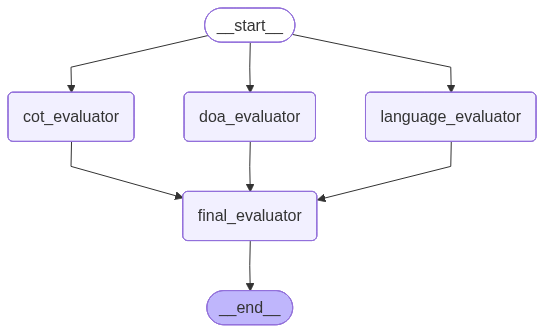

In [18]:
# Visualize the graph 
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [36]:
# Execute the graph
initial_state = {
    'essay':essay
}
workflow.invoke(initial_state)

{'essay': '\nEducation insaan ki zindagi ka bunyadi aur sab se aham pehlu hai. Yeh sirf kitaabi ilm hasil karne ka zariya nahi balkay sochne, samajhne aur behtar faislay karne ki salahiyat paida karti hai. Ek taleem-yafta insaan apni zindagi hi nahi balkay poori society ko behtar banane mein kirdar ada karta hai. Aaj ke modern aur competitive daur mein education ke baghair taraqqi ka tasawwur bhi mumkin nahi.\n\nSab se pehle, education insaan ki shakhsi taraqqi ka sabab banti hai. Taleem humein sahi aur ghalat mein farq sikhati hai, confidence paida karti hai aur decision-making skills ko behtar banati hai. Ek educated insaan apne haqooq aur zimmedariyon se waqif hota hai, jis ki wajah se woh society mein positive role play karta hai. Education se insan ka mindset broad hota hai aur woh mukhtalif masail ko logically handle karna seekhta hai.\n\nDoosri taraf, education maashi taraqqi mein bhi bohat aham kirdar ada karti hai. Aaj ke daur mein achi job aur stable career ke liye education 